In [39]:
import IPython.display as ipyd
from pyspark.sql.functions import col, regexp_replace, monotonically_increasing_id
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, monotonically_increasing_id, regexp_replace


In [40]:

spark = SparkSession.builder.getOrCreate()
df = spark.read.parquet("/home/iceberg/data/compras")
df = df.withColumn("id", monotonically_increasing_id())

df_typecasted = df.withColumn("ano", col("ano").cast("int")) \
                  .withColumn("mes", col("mes").cast("int")) \
                  .withColumn("Quantidade Item", col("Quantidade Item").cast("float")) \
                  .withColumn("Valor Item", regexp_replace(col("Valor Item"), ",", ".").cast("float"))

ids_to_remove = [25770005293, 25770005295]
df_typecasted = df_typecasted.filter(~col("id").isin(ids_to_remove))  # fix: col("id") not df["id"]

cardinality = sorted([
    (column, df_typecasted.select(F.approx_count_distinct(column)).collect()[0][0])
    for column in df_typecasted.columns if column != "id"
], key=lambda x: x[1])

ordered_cols = [c for c, _ in cardinality]

df_final = df_typecasted.select(ordered_cols) \
                        .orderBy(*[c for c, _ in cardinality])

In [41]:
spark.sql("CREATE NAMESPACE IF NOT EXISTS demo.compras")

df_final.writeTo("demo.compras.compras") \
        .tableProperty("format-version", "2") \
        .partitionedBy("ano", "mes") \
        .createOrReplace()

In [42]:
df_typecasted.printSchema()

root
 |-- Código Órgão: string (nullable = true)
 |-- Nome Órgão: string (nullable = true)
 |-- Código UG: string (nullable = true)
 |-- Nome UG: string (nullable = true)
 |-- Número Contrato: string (nullable = true)
 |-- Código Item Compra: string (nullable = true)
 |-- Descrição Item Compra: string (nullable = true)
 |-- Descrição Complementar Item Compra: string (nullable = true)
 |-- Quantidade Item: float (nullable = true)
 |-- Valor Item: float (nullable = true)
 |-- ano: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- id: long (nullable = false)



---

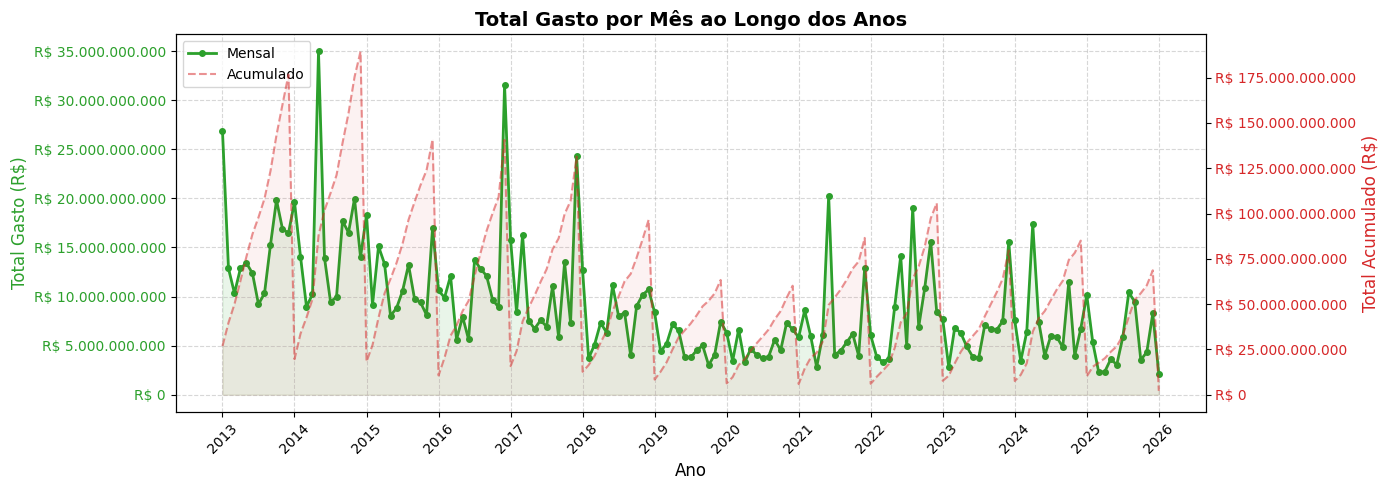

In [43]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, col

pdf = (
    df_typecasted
      .filter(
          (col("Valor Item") > 0) &
          (col("Quantidade Item") > 0) &
          (~col("id").isin([25770005293, 25770005295]))
      )
      .groupBy("ano", "mes")
      .agg(spark_sum("Valor Item").alias("total_valor"))
      .orderBy("ano", "mes")
      .toPandas()
)

pdf["month_index"] = (pdf["ano"] - pdf["ano"].min()) * 12 + (pdf["mes"] - 1)

pdf["cumsum_valor"] = pdf.groupby("ano")["total_valor"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))

ax2 = ax.twinx()
ax2.fill_between(pdf["month_index"], pdf["cumsum_valor"], alpha=0.06, color="#d62728")
ax2.plot(pdf["month_index"], pdf["cumsum_valor"], linewidth=1.5, color="#d62728", linestyle="--", alpha=0.5, label="Acumulado")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax2.set_ylabel("Total Acumulado (R$)", fontsize=12, color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax.plot(pdf["month_index"], pdf["total_valor"], marker="o", linewidth=2, color="#2ca02c", markersize=4, label="Mensal", zorder=3)
ax.fill_between(pdf["month_index"], pdf["total_valor"], alpha=0.1, color="#2ca02c")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax.set_ylabel("Total Gasto (R$)", fontsize=12, color="#2ca02c")
ax.tick_params(axis="y", labelcolor="#2ca02c")

years = pdf.drop_duplicates("ano").sort_values("ano")
tick_positions = ((years["ano"] - pdf["ano"].min()) * 12).tolist()
tick_labels = years["ano"].astype(str).tolist()
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_title("Total Gasto por Mês ao Longo dos Anos", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import pandas as pd
from pyspark.sql.window import Window

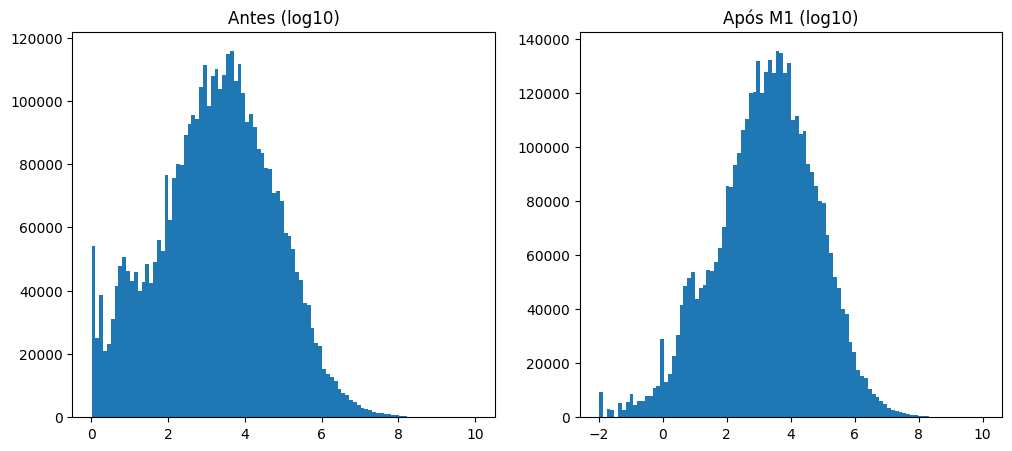

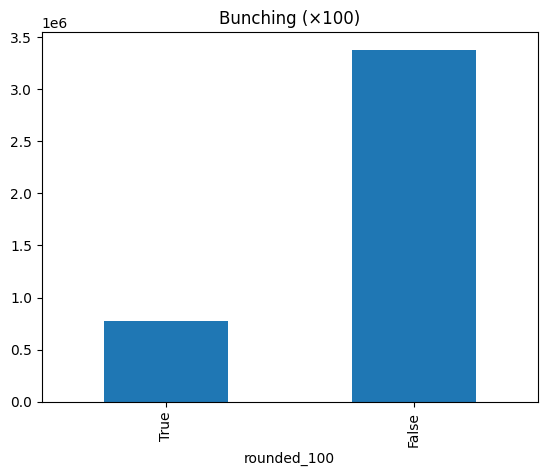

In [74]:
# =========================================
# M1 — ELIGIBILITY FILTER
# =========================================
df_model = (
    df_typecasted
    .filter((col("Valor Item") > 0) & (col("Quantidade Item") > 0))
    .withColumnRenamed("Valor Item", "value")
)

# LOG SAFE
df_model = df_model.withColumn("log_value", F.log10(col("value")))

# -------- VISUALIZAÇÃO M1 --------
pdf_raw = df_typecasted.select("Valor Item").dropna().toPandas()
pdf_model = df_model.select("value", "log_value").dropna().toPandas()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
pdf_raw = pdf_raw[pdf_raw["Valor Item"] > 0]  # remove zero e negativos
pdf_raw = pdf_raw.dropna()
plt.hist(np.log10(pdf_raw["Valor Item"] + 1), bins=100)
plt.title("Antes (log10)")

plt.subplot(1,2,2)
plt.hist(pdf_model["log_value"], bins=100)
plt.title("Após M1 (log10)")

plt.show()

# BUNCHING
df_model.withColumn("rounded_100", col("value") % 100 == 0) \
    .groupBy("rounded_100") \
    .count() \
    .toPandas() \
    .set_index("rounded_100") \
    .plot(kind="bar", legend=False)

plt.title("Bunching (×100)")
plt.show()

In [86]:
# =========================================
# HELPERS
# =========================================
def first_digit():
    return F.substring(F.regexp_replace(col("value").cast("string"), "[^0-9]", ""), 1, 1).cast("int")

def first_two_digits():                                 
    return F.substring(F.regexp_replace(col("value").cast("string"), "[^0-9]", ""), 1, 2).cast("int")

def last_digit():
    return (col("value") % 10).cast("int")

# =========================================
# FEATURE ENGINEERING (atualizado conforme pipeline)
# =========================================
df_feat = df_model \
    .withColumn("d1",  first_digit()) \
    .withColumn("d12", first_two_digits()) \
    .withColumn("ld",  last_digit())

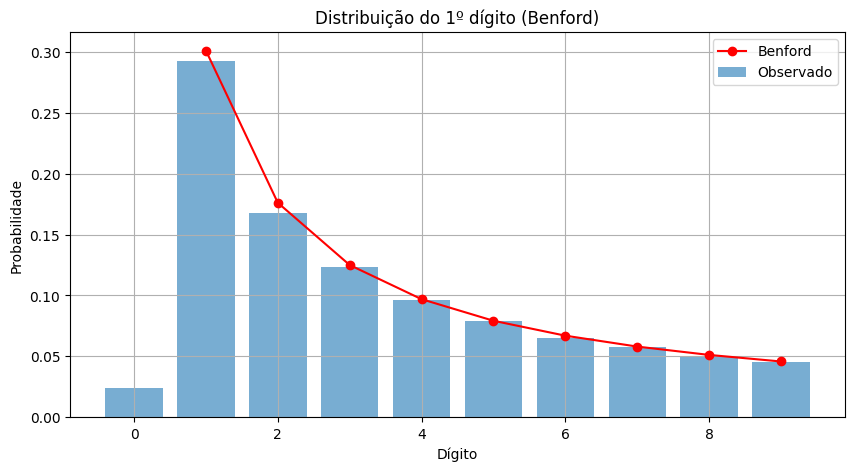

In [87]:
df1 = df_feat.withColumn("digit", first_digit())

obs = df1.groupBy("digit").count().orderBy("digit").toPandas()
obs["p_obs"] = obs["count"] / obs["count"].sum()

exp = pd.DataFrame({
    "digit": list(range(1,10)),
    "p_exp": [np.log10(1+1/d) for d in range(1,10)]
})

plt.figure(figsize=(10,5))
plt.bar(obs["digit"], obs["p_obs"], alpha=0.6, label="Observado")
plt.plot(exp["digit"], exp["p_exp"], color="red", marker="o", label="Benford")
plt.title("Distribuição do 1º dígito (Benford)")
plt.xlabel("Dígito")
plt.ylabel("Probabilidade")
plt.legend()
plt.grid()
plt.show()

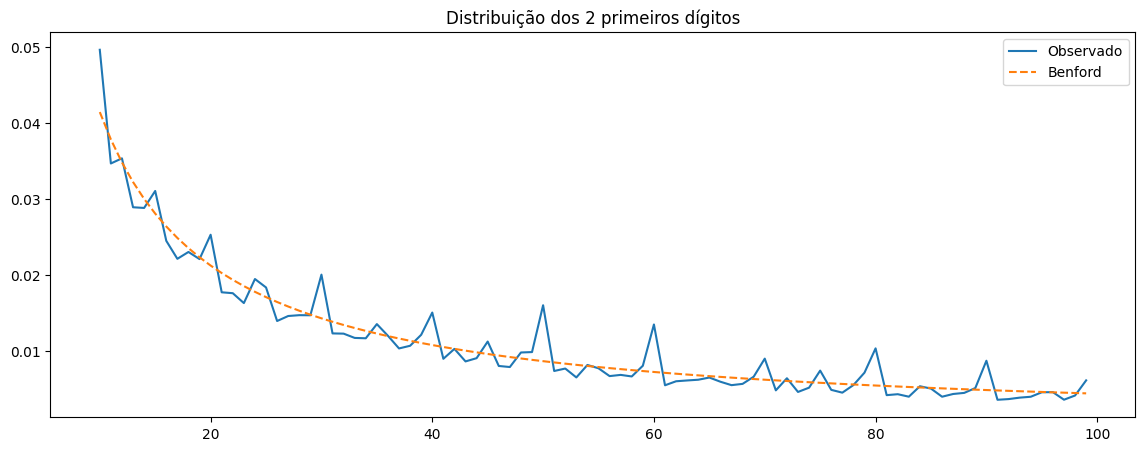

In [88]:
df2 = df_feat.withColumn("digit", first_two_digits()).filter(col("digit").between(10,99))

obs2 = df2.groupBy("digit").count().orderBy("digit").toPandas()
obs2["p_obs"] = obs2["count"] / obs2["count"].sum()

exp2 = pd.DataFrame({
    "digit": list(range(10,100)),
    "p_exp": [np.log10(1+1/n) for n in range(10,100)]
})

plt.figure(figsize=(14,5))
plt.plot(obs2["digit"], obs2["p_obs"], label="Observado")
plt.plot(exp2["digit"], exp2["p_exp"], label="Benford", linestyle="--")
plt.title("Distribuição dos 2 primeiros dígitos")
plt.legend()
plt.show()

In [89]:
# =========================================
# M2 — STATISTICAL ENGINE (implementação EXATA do pipeline do SVG)
# =========================================
from pyspark.sql import functions as F
import numpy as np
import pandas as pd

# ===================== BENFORD 1º DÍGITO =====================
benford_1d = spark.createDataFrame([
    (d, float(np.log10(1 + 1.0/d))) for d in range(1, 10)
], ["d1", "p_exp"])

obs_1d = (df_feat
    .filter(F.col("d1").between(1, 9))
    .groupBy("d1")
    .count()
    .withColumnRenamed("count", "O"))

N1 = obs_1d.agg(F.sum("O")).first()[0]
obs_1d = obs_1d.withColumn("p_obs", F.col("O") / N1)
obs_1d = obs_1d.join(benford_1d, "d1")

obs_1d = obs_1d.withColumn(
    "Z", (F.col("p_obs") - F.col("p_exp")) / F.sqrt((F.col("p_exp") * (1 - F.col("p_exp"))) / N1)
)
obs_1d = obs_1d.withColumn("abs_dev", F.abs(F.col("p_obs") - F.col("p_exp")))

# JS Divergence (simétrica - conforme SVG)
pdf_1d = obs_1d.select("p_obs", "p_exp").toPandas()
p = pdf_1d["p_obs"].values
q = pdf_1d["p_exp"].values
m = 0.5 * (p + q)
js_1d = 0.5 * np.sum(p * np.log2(p / m)) + 0.5 * np.sum(q * np.log2(q / m))

mad_1d = obs_1d.agg(F.mean("abs_dev").alias("MAD")).first()["MAD"]

print(f"\n=== BENFORD 1º DÍGITO (SVG Lane 1) ===")
print(f"N = {N1:,} | MAD = {mad_1d:.5f} | JS = {js_1d:.5f}")
display(obs_1d.select("d1", "O", F.round("p_obs",4).alias("p_obs"),
                       F.round("p_exp",4).alias("p_exp"), F.round("Z",3).alias("Z"),
                       F.round("abs_dev",5).alias("abs_dev")).orderBy("d1"))

# ===================== BENFORD 2 DÍGITOS =====================
benford_2d = spark.createDataFrame([
    (d, float(np.log10(1 + 1.0/d))) for d in range(10, 100)
], ["d12", "p_exp"])

obs_2d = (df_feat
    .filter(F.col("d12").between(10, 99))
    .groupBy("d12")
    .count()
    .withColumnRenamed("count", "O"))

N2 = obs_2d.agg(F.sum("O")).first()[0]
obs_2d = obs_2d.withColumn("p_obs", F.col("O") / N2)
obs_2d = obs_2d.join(benford_2d, "d12")

obs_2d = obs_2d.withColumn(
    "Z", (F.col("p_obs") - F.col("p_exp")) / F.sqrt((F.col("p_exp") * (1 - F.col("p_exp"))) / N2)
)
obs_2d = obs_2d.withColumn("abs_dev", F.abs(F.col("p_obs") - F.col("p_exp")))

# JS Divergence (evasão - conforme SVG)
pdf_2d = obs_2d.select("p_obs", "p_exp").toPandas()
p = pdf_2d["p_obs"].values
q = pdf_2d["p_exp"].values
m = 0.5 * (p + q)
js_2d = 0.5 * np.sum(p * np.log2(p / m)) + 0.5 * np.sum(q * np.log2(q / m))

mad_2d = obs_2d.agg(F.mean("abs_dev").alias("MAD")).first()["MAD"]

print(f"\n=== BENFORD 2 DÍGITOS (SVG Lane 2) ===")
print(f"N = {N2:,} | MAD = {mad_2d:.5f} | JS = {js_2d:.5f}")
display(obs_2d.select("d12", "O", F.round("p_obs",4).alias("p_obs"),
                       F.round("p_exp",4).alias("p_exp"), F.round("Z",3).alias("Z"),
                       F.round("abs_dev",5).alias("abs_dev")).orderBy("d12").limit(15))

# ===================== ÚLTIMO DÍGITO (Uniforme) =====================
obs_ld = (df_feat
    .groupBy("ld")
    .count()
    .withColumnRenamed("count", "O"))

N_ld = obs_ld.agg(F.sum("O")).first()[0]
obs_ld = obs_ld.withColumn("p_obs", F.col("O") / N_ld)
obs_ld = obs_ld.withColumn("p_exp", F.lit(0.1))

# χ² uniforme (conforme SVG)
obs_ld = obs_ld.withColumn(
    "chi2_term", F.pow(F.col("O") - N_ld/10, 2) / (N_ld/10)
)
chi2_ld = obs_ld.agg(F.sum("chi2_term").alias("chi2")).first()["chi2"]

obs_ld = obs_ld.withColumn("abs_dev", F.abs(F.col("p_obs") - 0.1))

mad_ld = obs_ld.agg(F.mean("abs_dev").alias("MAD")).first()["MAD"]

print(f"\n=== ÚLTIMO DÍGITO (SVG Lane 3) ===")
print(f"N = {N_ld:,} | χ² = {chi2_ld:.2f} | MAD = {mad_ld:.5f}")
display(obs_ld.select("ld", "O", F.round("p_obs",4).alias("p_obs"),
                       F.round("abs_dev",5).alias("abs_dev")).orderBy("ld"))

[Stage 1802:===================================================>  (18 + 1) / 19]


=== BENFORD 1º DÍGITO (SVG Lane 1) ===
N = 4,050,618 | MAD = 0.00130 | JS = 0.00004


DataFrame[d1: int, O: bigint, p_obs: double, p_exp: double, Z: double, abs_dev: double]

[Stage 1823:===================================================>  (18 + 1) / 19]


=== BENFORD 2 DÍGITOS (SVG Lane 2) ===
N = 4,050,618 | MAD = 0.00148 | JS = 0.00591


DataFrame[d12: int, O: bigint, p_obs: double, p_exp: double, Z: double, abs_dev: double]

[Stage 1844:================================================>     (17 + 2) / 19]


=== ÚLTIMO DÍGITO (SVG Lane 3) ===
N = 4,151,095 | χ² = 4013739.91 | MAD = 0.05881


DataFrame[ld: int, O: bigint, p_obs: double, abs_dev: double]

In [90]:
# =========================================
# M3 — MICRO (Z-score local por contrato) — mantido
# =========================================
w_local = Window.partitionBy("Número Contrato")
df_feat = df_feat.withColumn("mean_local", F.avg("value").over(w_local))
df_feat = df_feat.withColumn("std_local", F.stddev("value").over(w_local))
df_feat = df_feat.withColumn(
    "z_local",
    F.when(col("std_local") > 0, (col("value") - col("mean_local")) / col("std_local")).otherwise(0)
)


Threshold (85% quantile): 17.4084


+---------------+------------+------------------+------------------+-----------------+--------------------+
|Número Contrato|value       |score             |Z_d1_abs          |Z_d12_abs        |abs_dev_ld          |
+---------------+------------+------------------+------------------+-----------------+--------------------+
|92017          |5.0917E7    |44.116077630449375|14.638020817261598|160.5307180686963|0.29404639016934087 |
|92017          |5.0917E7    |44.116077630449375|14.638020817261598|160.5307180686963|0.29404639016934087 |
|000022021      |5.0678684E7 |42.40920248855183 |14.638020817261598|160.5307180686963|0.030860652430262384|
|000022021      |5.0678684E7 |42.40920248855183 |14.638020817261598|160.5307180686963|0.030860652430262384|
|000202024      |5.0E7       |42.19737115893829 |14.638020817261598|160.5307180686963|0.29404639016934087 |
|312018         |5.0E7       |41.55067170471091 |14.638020817261598|160.5307180686963|0.29404639016934087 |
|312018         |5.0E7      

+--------+-------+------------------+------------------+
|suspeito|   qtde|       valor_medio|       score_medio|
+--------+-------+------------------+------------------+
|    true| 640997|330682.18218269065|22.566178953990008|
|   false|3510098| 346196.7816139564|7.0702601556884135|
+--------+-------+------------------+------------------+



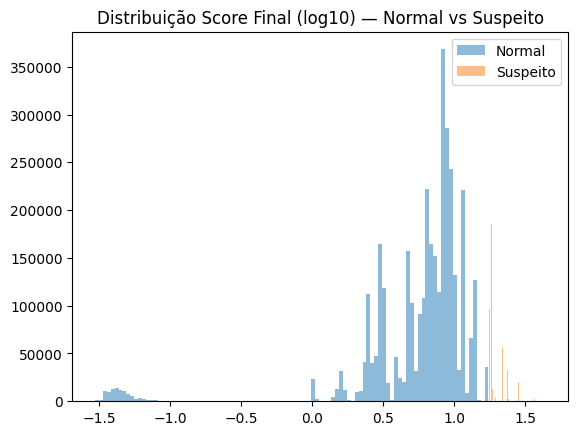

In [91]:
# =========================================
# M4 — SCORE COMPOSTO (exatamente conforme pesos do SVG)
# =========================================
# Join das anomalias por dígito de volta ao dataframe
df_feat = df_feat.join(
    obs_1d.select("d1", F.abs("Z").alias("Z_d1_abs"), "abs_dev").withColumnRenamed("abs_dev", "abs_dev_d1"),
    "d1", "left"
)

df_feat = df_feat.join(
    obs_2d.select("d12", F.abs("Z").alias("Z_d12_abs"), "abs_dev").withColumnRenamed("abs_dev", "abs_dev_d12"),
    "d12", "left"
)

df_feat = df_feat.join(
    obs_ld.select("ld", "abs_dev").withColumnRenamed("abs_dev", "abs_dev_ld"),
    "ld", "left"
)

df_feat = df_feat.fillna(0)

# Score Composto (pesos exatos do diagrama SVG)
df_feat = df_feat.withColumn(
    "score",
    0.30 * F.col("Z_d1_abs") +          # JS_1d / Z 1º dígito
    0.25 * F.col("abs_dev_d1") +        # MAD 1º dígito
    0.20 * F.col("Z_d12_abs") +         # JS_2d
    0.15 * F.abs(col("z_local")) +      # Z local (micro)
    0.10 * F.col("abs_dev_ld")          # Último dígito
)

# Normalização opcional (0-1) para facilitar threshold
max_score = df_feat.agg(F.max("score")).first()[0]
df_feat = df_feat.withColumn("score_norm", col("score") / max_score)

# =========================================
# DETECÇÃO FINAL
# =========================================
threshold = df_feat.select("score").sample(0.2).approxQuantile("score", [0.85], 0.05)[0]

df_result = df_feat.withColumn("suspeito", col("score") > threshold)

print(f"\nThreshold (85% quantile): {threshold:.4f}")
df_result.filter(col("suspeito")) \
    .orderBy(F.desc("score")) \
    .select("Número Contrato", "value", "score", "Z_d1_abs", "Z_d12_abs", "abs_dev_ld") \
    .show(20, False)

df_result.groupBy("suspeito").agg(
    F.count("*").alias("qtde"),
    F.avg("value").alias("valor_medio"),
    F.avg("score").alias("score_medio")
).show()

# Visualização final (mantida)
pdf_score = df_result.select("score", "suspeito").toPandas()
plt.hist(np.log10(pdf_score[pdf_score["suspeito"]==False]["score"] + 1e-6), bins=100, alpha=0.5, label="Normal")
plt.hist(np.log10(pdf_score[pdf_score["suspeito"]==True]["score"] + 1e-6), bins=100, alpha=0.5, label="Suspeito")
plt.title("Distribuição Score Final (log10) — Normal vs Suspeito")
plt.legend()
plt.show()

---
## M5 -- Synthetic Validation + ROC
> Injecao sintetica de fraude (1%-30%) -> TPR/FPR -> AUC.
> Formulas do TCC: MAD eq.2.6, JSD eq.2.8-2.9, Z-Score eq.2.7, LDT eq.2.10, R eq.2.11.

In [53]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.sql import functions as F
from pyspark.sql.functions import col, rand
from pyspark.sql.types import DoubleType, IntegerType

In [55]:
# ------------------------------------------------------------------
# 5.1  INJECAO DE FRAUDE SINTETICA (bunching)
# ------------------------------------------------------------------
# Substitui fraud_rate dos registros por valores ligeiramente abaixo
# dos limiares da Lei 14.133/2021 -- simula bunching (Signor et al. 2020)

THRESHOLDS_14133 = [100_000.0, 50_000.0, 10_000.0]

def inject_fraud_spark(df, fraud_rate, seed=42):
    from pyspark.sql.functions import udf
    thr_bc = df.sparkSession.sparkContext.broadcast(THRESHOLDS_14133)

    @udf(DoubleType())
    def synthetic_value(v, flag):
        if flag == 0:
            return float(v)
        thr = None
        for t in sorted(thr_bc.value, reverse=True):
            if v is not None and float(v) <= t * 1.15:
                thr = t
                break
        if thr is None:
            thr = thr_bc.value[-1]
        import random as _r
        _r.seed(flag)
        return float(thr * _r.uniform(0.88, 0.995))

    return (
        df.withColumn('_rnd', rand(seed=seed))
          .withColumn('_fraud_flag', (col('_rnd') < fraud_rate).cast(IntegerType()))
          .withColumn('value_synth', synthetic_value(col('value'), col('_fraud_flag')))
          .drop('_rnd')
    )

In [56]:
# ------------------------------------------------------------------
# 5.2  MOTOR ESTATISTICO ESCALAR
# ------------------------------------------------------------------

def benford_expected():
    d = np.arange(1, 10)
    return dict(zip(d, np.log10(1 + 1/d)))

def extract_d1(series):
    s = series.astype(str).str.replace(r'[^0-9]', '', regex=True).str[0]
    return pd.to_numeric(s, errors='coerce').dropna().astype(int)

def compute_mad(values):
    # MAD = (1/k) * sum(|P_obs(d) - P_exp(d)|)  -- Nigrini (2012) eq. 2.6
    d1 = extract_d1(values)
    p_exp = benford_expected()
    counts = d1.value_counts(normalize=True)
    return sum(abs(counts.get(d, 0) - p_exp[d]) for d in range(1, 10)) / 9

def compute_jsd(values):
    # JSD(P||Q) = 0.5*DKL(P||M) + 0.5*DKL(Q||M)  -- Lin (1991) eq. 2.8-2.9
    d1 = extract_d1(values)
    p_exp = benford_expected()
    counts = d1.value_counts(normalize=True)
    p_p = np.array([counts.get(d, 1e-10) for d in range(1, 10)])
    p_q = np.array([p_exp[d] for d in range(1, 10)])
    m   = 0.5 * (p_p + p_q)
    kl  = lambda a, b: np.sum(a * np.log2(np.where(a > 0, a / b, 1)))
    return 0.5 * kl(p_p, m) + 0.5 * kl(p_q, m)

def compute_zscore_max(values, N):
    # Z(d) numerador = |P_obs - P_exp| - 1/(2N)  (correcao Yates)
    # Z(d) denominador = sqrt(P_exp*(1-P_exp)/N)
    # Retorna max Z entre todos os digitos -- eq. 2.7 do TCC
    d1 = extract_d1(values)
    p_exp = benford_expected()
    counts = d1.value_counts(normalize=True)
    zs = []
    for d in range(1, 10):
        p_o = counts.get(d, 0)
        p_e = p_exp[d]
        num = abs(p_o - p_e) - (1.0 / (2 * N))
        den = np.sqrt(p_e * (1 - p_e) / N)
        zs.append(num / den if den > 0 else 0.0)
    return float(max(zs))

def compute_ldt_chi2(values):
    # chi2_LD = sum( (O_d - N/10)^2 / (N/10) )  -- eq. 2.10 do TCC
    ld  = (values.astype(float).astype(int) % 10)
    N   = len(ld)
    exp = N / 10
    return float(sum((ld.value_counts().get(d, 0) - exp)**2 / exp for d in range(10)))

def composite_score_lhs(mad, jsd, z_max, ldt_chi2, n_samples=1000, seed=42):
    # R = w1*f(MAD) + w2*f(JSD) + w3*f(Zmax) + w4*f(LDT)  -- eq. 2.11
    # Pesos via LHS (McKay, Beckman & Conover, 1979)
    rng = np.random.default_rng(seed)
    K   = 4
    smp = np.zeros((n_samples, K))
    for k in range(K):
        perm    = rng.permutation(n_samples)
        u       = (perm + rng.uniform(size=n_samples)) / n_samples
        smp[:, k] = u
    w = smp / smp.sum(axis=1, keepdims=True)
    f = np.array([
        min(mad / 0.015,  1.0),
        min(jsd,          1.0),
        min(z_max / 10.0, 1.0),
        min(ldt_chi2 / 50.0, 1.0),
    ])
    R = w @ f
    return float(np.median(R)), float(np.percentile(R, 95))

In [57]:
# ------------------------------------------------------------------
# 5.3  LOOP DE VALIDACAO: fraude 1%-30%
# ------------------------------------------------------------------
FRAUD_RATES = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
df_base  = df_result.select('value', 'score').dropna()
results  = []

for fr in FRAUD_RATES:
    df_synth  = inject_fraud_spark(df_base, fraud_rate=fr)
    pdf_synth = df_synth.select('value', 'value_synth', '_fraud_flag', 'score').toPandas()
    N_total   = len(pdf_synth)

    mad_v = compute_mad(pdf_synth['value_synth'])
    jsd_v = compute_jsd(pdf_synth['value_synth'])
    z_v   = compute_zscore_max(pdf_synth['value_synth'], N_total)
    ldt_v = compute_ldt_chi2(pdf_synth['value_synth'])
    r_med, r_p95 = composite_score_lhs(mad_v, jsd_v, z_v, ldt_v)

    results.append({
        'fraud_rate': fr, 'MAD': mad_v, 'JSD': jsd_v, 'Z_max': z_v,
        'LDT_chi2': ldt_v, 'R_median': r_med, 'R_p95': r_p95,
        'y_true':  pdf_synth['_fraud_flag'].values,
        'y_score': pdf_synth['score'].values,
    })
    print(f"  fr={fr:.0%}  MAD={mad_v:.5f}  JSD={jsd_v:.4f}  "
          f"Z={z_v:.2f}  LDT={ldt_v:.1f}  R_med={r_med:.3f}")

  fr=1%  MAD=0.00239  JSD=0.0003  Z=81.81  LDT=3448427.3  R_med=0.544


  fr=2%  MAD=0.00417  JSD=0.0011  Z=168.34  LDT=3373281.7  R_med=0.571


  fr=5%  MAD=0.01038  JSD=0.0058  Z=426.75  LDT=3188977.1  R_med=0.674


  fr=10%  MAD=0.02095  JSD=0.0188  Z=861.18  LDT=3010045.7  R_med=0.752


  fr=15%  MAD=0.03155  JSD=0.0359  Z=1296.90  LDT=2993854.4  R_med=0.757


  fr=20%  MAD=0.04209  JSD=0.0558  Z=1730.46  LDT=3145419.8  R_med=0.762


  fr=25%  MAD=0.05267  JSD=0.0782  Z=2165.36  LDT=3459652.1  R_med=0.767


  fr=30%  MAD=0.06321  JSD=0.1026  Z=2598.49  LDT=3941082.2  R_med=0.773


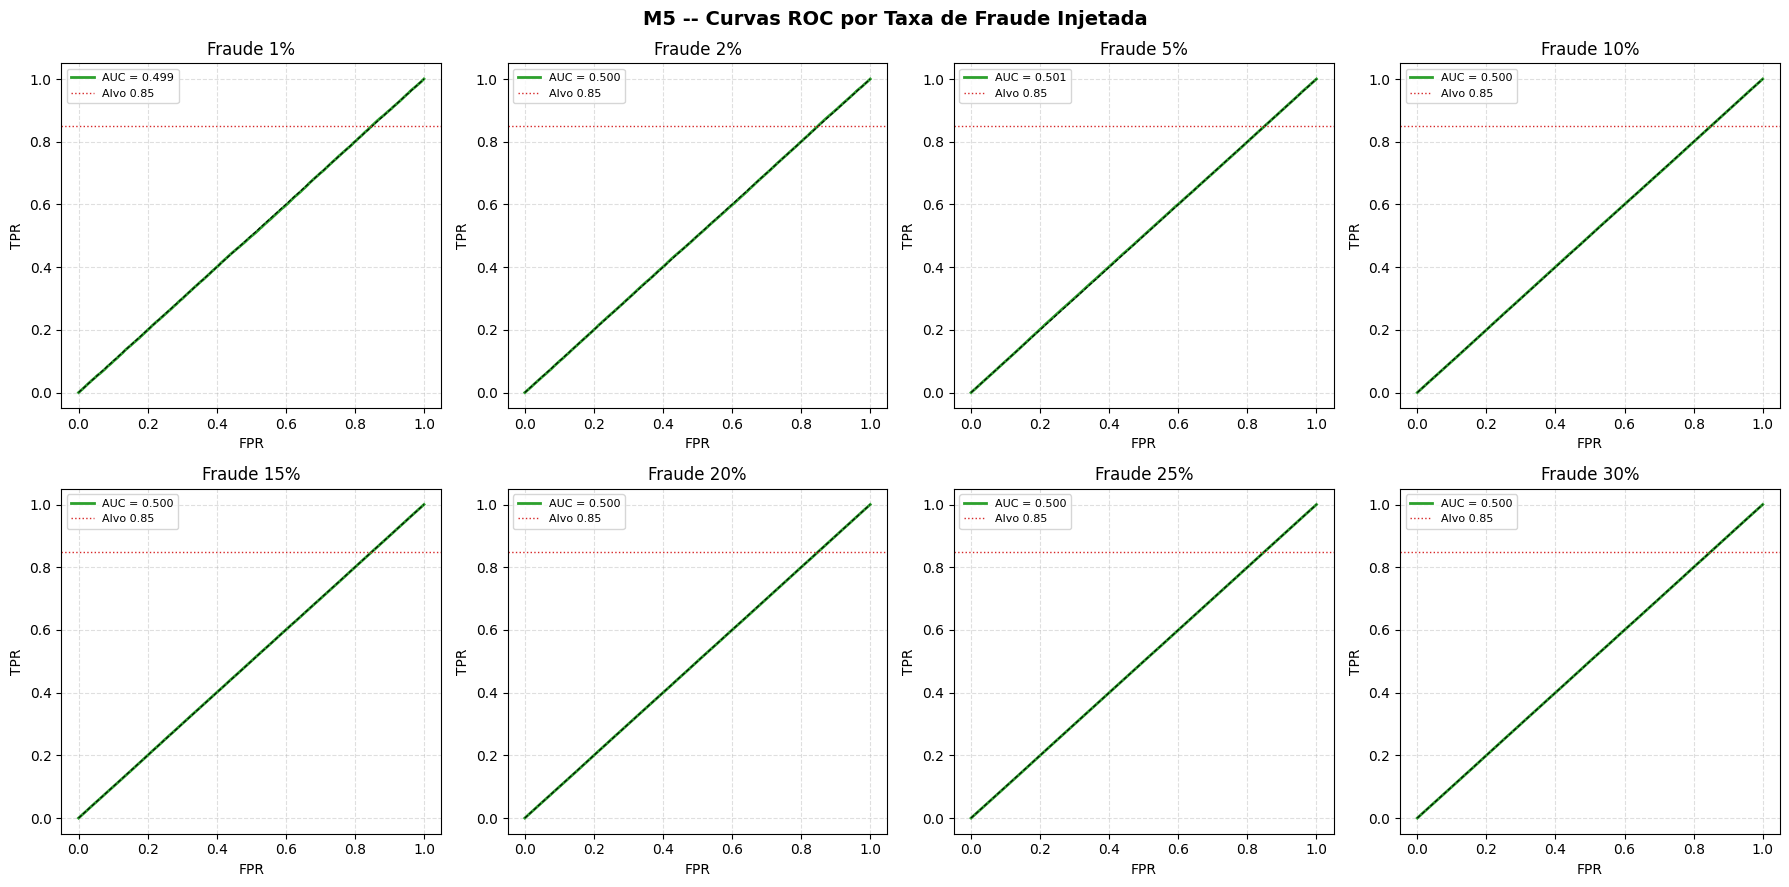

In [58]:
# ------------------------------------------------------------------
# 5.4  CURVAS ROC + AUC
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
auc_values = []

for i, res in enumerate(results):
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_score'])
    roc_auc = auc(fpr, tpr)
    auc_values.append(roc_auc)
    axes[i].plot(fpr, tpr, lw=2, color='#2ca02c', label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0,1],[0,1], 'k--', lw=0.8)
    axes[i].axhline(0.85, color='#d62728', linestyle=':', lw=1, label='Alvo 0.85')
    axes[i].set_title(f"Fraude {res['fraud_rate']:.0%}")
    axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR')
    axes[i].legend(fontsize=8); axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('M5 -- Curvas ROC por Taxa de Fraude Injetada', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


=== M5 -- Resumo Validacao Sintetica ===
Taxa Fraude      MAD     JSD   Z_max  LDT chi2  R_mediana  R_p95    AUC AUC>=0.85
         1% 0.002388 0.00031   81.81 3448427.3     0.5443 0.7905 0.4995      FAIL
         2% 0.004174 0.00112  168.34 3373281.7     0.5705 0.8064 0.5000      FAIL
         5% 0.010381 0.00583  426.75 3188977.1     0.6737 0.8768 0.5007      FAIL
        10% 0.020949 0.01881  861.18 3010045.7     0.7523 0.9693 0.5000      FAIL
        15% 0.031548 0.03589 1296.90 2993854.4     0.7566 0.9699 0.5000      FAIL
        20% 0.042094 0.05579 1730.46 3145419.8     0.7616 0.9705 0.4998      FAIL
        25% 0.052673 0.07815 2165.36 3459652.1     0.7673 0.9712 0.4997      FAIL
        30% 0.063209 0.10260 2598.49 3941082.2     0.7734 0.9719 0.4999      FAIL


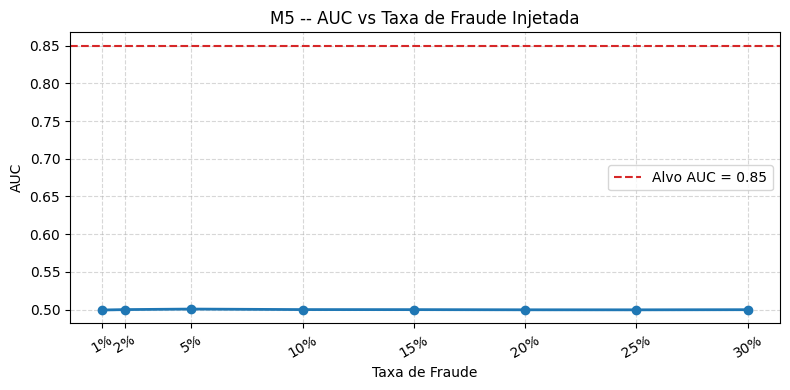

In [59]:
# ------------------------------------------------------------------
# 5.5  RESUMO TABULAR
# ------------------------------------------------------------------
summary_m5 = pd.DataFrame([{
    'Taxa Fraude': f"{r['fraud_rate']:.0%}",
    'MAD':         round(r['MAD'], 6),
    'JSD':         round(r['JSD'], 5),
    'Z_max':       round(r['Z_max'], 2),
    'LDT chi2':    round(r['LDT_chi2'], 1),
    'R_mediana':   round(r['R_median'], 4),
    'R_p95':       round(r['R_p95'], 4),
    'AUC':         round(auc_values[j], 4),
    'AUC>=0.85':   'OK' if auc_values[j] >= 0.85 else 'FAIL',
} for j, r in enumerate(results)])

print('\n=== M5 -- Resumo Validacao Sintetica ===')
print(summary_m5.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot([r['fraud_rate'] for r in results], auc_values,
         marker='o', color='#1f77b4', linewidth=2)
plt.axhline(0.85, color='#d62728', linestyle='--', label='Alvo AUC = 0.85')
plt.title('M5 -- AUC vs Taxa de Fraude Injetada')
plt.xlabel('Taxa de Fraude'); plt.ylabel('AUC')
plt.xticks([r['fraud_rate'] for r in results],
           [f"{r['fraud_rate']:.0%}" for r in results], rotation=30)
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

---
## M6 -- Threshold / Bunching Analysis
> KDE por orgao · IAB (Indice de Anomalia de Bunching) · Last Digit Test · Lei 14.133/2021.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pyspark.sql import functions as F
from pyspark.sql.functions import col

In [61]:
# ------------------------------------------------------------------
# 6.1  DICIONARIO DE LIMIARES -- Lei 14.133/2021, art. 75
# ------------------------------------------------------------------
THRESHOLD_DICT = {
    'obras_servicos_engenharia':      200_000.0,
    'servicos_e_compras':             100_000.0,
    'consorcio_publico_obras':        400_000.0,
    'consorcio_publico_compras':      200_000.0,
    'setor_seguranca_defesa_obras':    50_000.0,
    'setor_seguranca_defesa_compras':  30_000.0,
}
DEFAULT_THRESHOLD = THRESHOLD_DICT['servicos_e_compras']  # R$ 100.000
WINDOW_LOWER = 0.80
WINDOW_UPPER = 1.00

In [62]:
# ------------------------------------------------------------------
# 6.2  IAB -- INDICE DE ANOMALIA DE BUNCHING
# ------------------------------------------------------------------
# IAB = (N_bunching - N_expected) / N_expected
#
# N_bunching = contratos em [T*WINDOW_LOWER, T*WINDOW_UPPER)
# N_expected = densidade uniforme estimada na vizinhanca [T*0.50, T*1.50]
#              projetada sobre a janela de bunching
#
# IAB > 0 indica excesso de contratos abaixo do limiar (sinal de bunching)
# Baseado em Signor et al. (2020) e Last Digit Test de Nigrini (2012)

def compute_iab(values, threshold,
                window_lower=0.80, window_upper=1.00,
                neighbor_lower=0.50, neighbor_upper=1.50):
    v = values.dropna()
    v = v[v > 0]
    t_low = threshold * window_lower;   t_high = threshold * window_upper
    n_low = threshold * neighbor_lower; n_high = threshold * neighbor_upper

    N_bunching = int(((v >= t_low) & (v < t_high)).sum())
    N_neighbor = int(((v >= n_low) & (v < n_high)).sum())

    window_width   = t_high - t_low
    neighbor_width = n_high - n_low
    N_expected = (N_neighbor / neighbor_width) * window_width if neighbor_width > 0 else 1
    iab = (N_bunching - N_expected) / N_expected if N_expected > 0 else 0.0
    return {'N_bunching': N_bunching, 'N_expected': round(float(N_expected), 1),
            'IAB': round(float(iab), 4)}

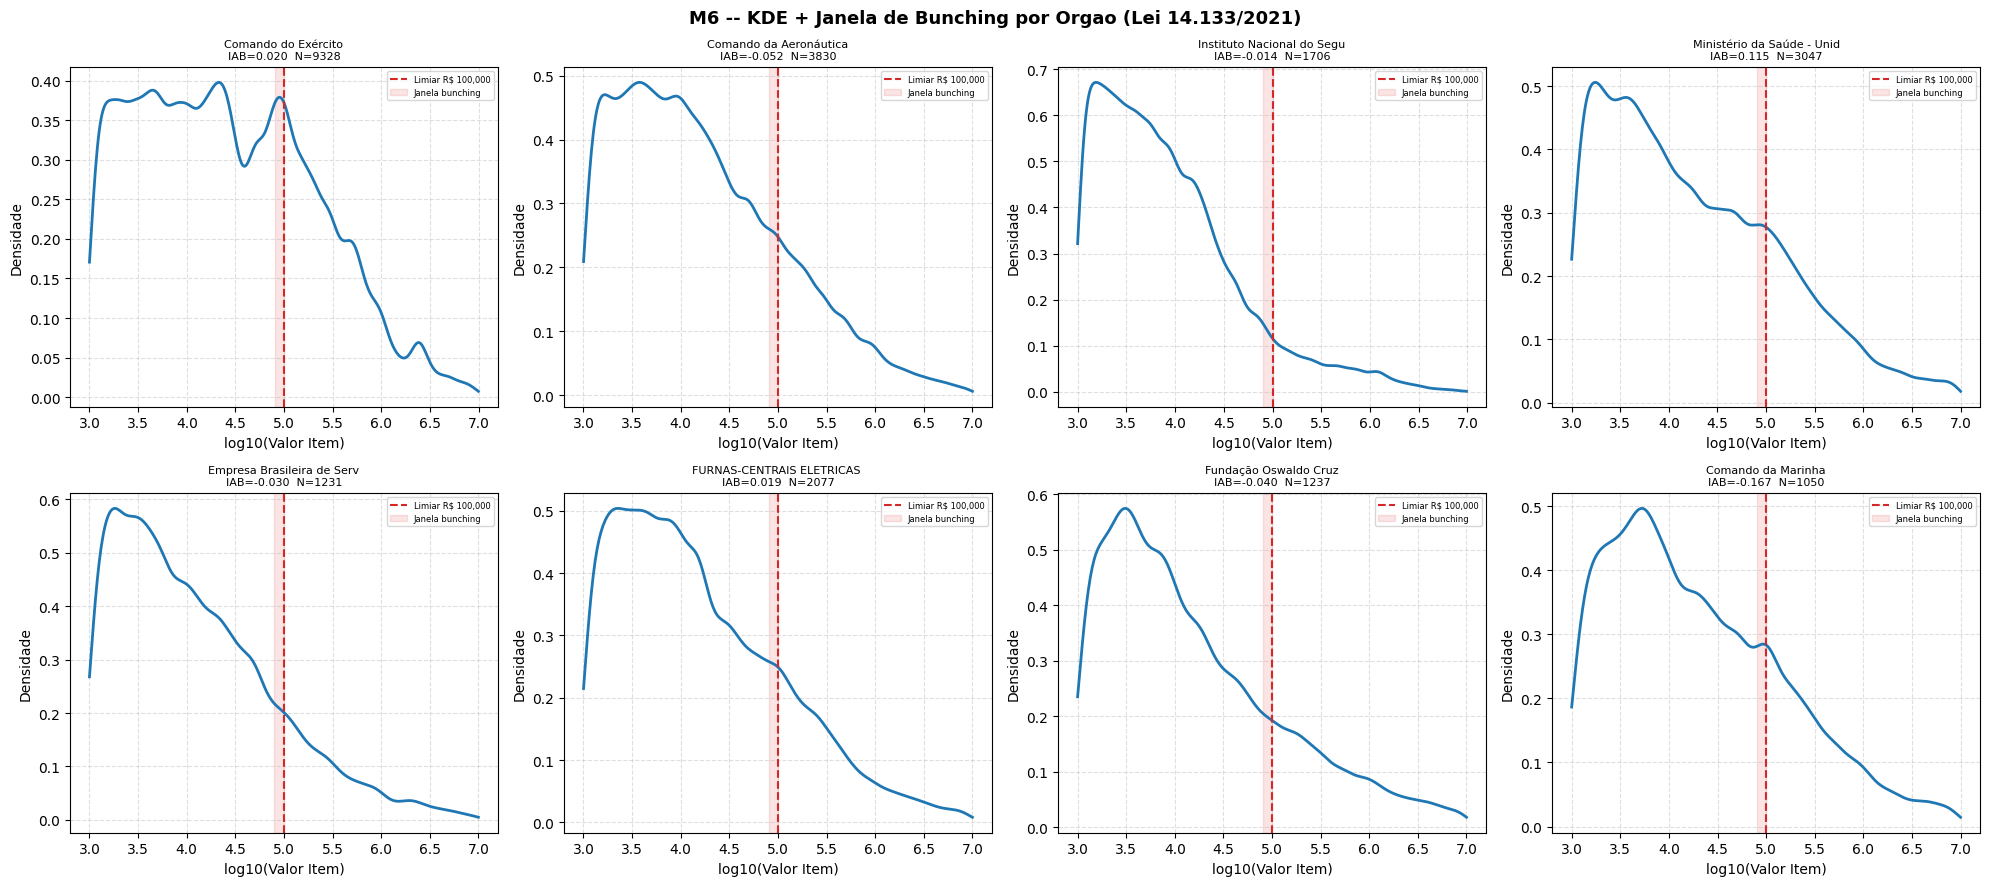

In [63]:
# ------------------------------------------------------------------
# 6.3  KDE + IAB POR ORGAO (top-8 por volume)
# ------------------------------------------------------------------
_cols = df_result.columns
ORGAO_CODE = next((c for c in _cols if 'digo' in c and 'rg' in c), _cols[0])
ORGAO_NAME = next((c for c in _cols if 'Nome' in c and 'rg' in c), _cols[1])

pdf_bunching = (
    df_result
    .filter(col('value') > 0)
    .select(ORGAO_CODE, ORGAO_NAME, 'value', 'suspeito')
    .dropna()
    .toPandas()
    .rename(columns={ORGAO_CODE: 'cod_orgao', ORGAO_NAME: 'nome_orgao'})
)

top_orgaos  = pdf_bunching['cod_orgao'].value_counts().head(8).index.tolist()
iab_results = []

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, orgao in enumerate(top_orgaos):
    sub  = pdf_bunching[pdf_bunching['cod_orgao'] == orgao]['value'].dropna()
    sub  = sub[(sub > 1_000) & (sub < 10_000_000)]
    nome = pdf_bunching[pdf_bunching['cod_orgao'] == orgao]['nome_orgao'].iloc[0]

    iab_info = compute_iab(sub, DEFAULT_THRESHOLD)
    iab_results.append({'Orgao': orgao, 'Nome': nome[:30], **iab_info})

    ax = axes[idx]
    if len(sub) > 10:
        log_vals = np.log10(sub + 1)
        kde = gaussian_kde(log_vals, bw_method='scott')
        x_grid = np.linspace(log_vals.min(), log_vals.max(), 400)
        ax.plot(x_grid, kde(x_grid), color='#1f77b4', lw=2)

    ax.axvline(np.log10(DEFAULT_THRESHOLD), color='#d62728',
               linestyle='--', lw=1.5, label=f'Limiar R$ {DEFAULT_THRESHOLD:,.0f}')
    ax.axvspan(np.log10(DEFAULT_THRESHOLD * WINDOW_LOWER),
               np.log10(DEFAULT_THRESHOLD * WINDOW_UPPER),
               alpha=0.12, color='#d62728', label='Janela bunching')
    ax.set_title(f"{nome[:26]}\nIAB={iab_info['IAB']:.3f}  N={iab_info['N_bunching']}",
                 fontsize=8)
    ax.set_xlabel('log10(Valor Item)'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=6); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('M6 -- KDE + Janela de Bunching por Orgao (Lei 14.133/2021)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

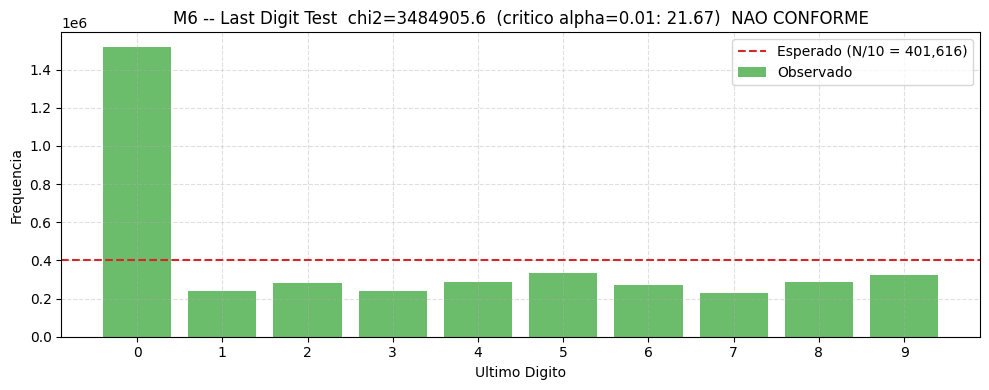

In [64]:
# ------------------------------------------------------------------
# 6.4  LAST DIGIT TEST GLOBAL  (Nigrini 2012 eq. 2.10)
# chi2_LD = sum( (O_d - N/10)^2 / (N/10) )  9 g.l.
# ------------------------------------------------------------------
ld_series = (np.floor(pdf_bunching['value']).astype('int64') % 10)
N_ld      = len(ld_series)
exp_ld    = N_ld / 10
chi2_obs  = {d: int((ld_series == d).sum()) for d in range(10)}
chi2_stat = sum((chi2_obs[d] - exp_ld)**2 / exp_ld for d in range(10))
chi2_crit = 21.67  # chi2 9 g.l., alpha=0.01

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(list(chi2_obs.keys()), list(chi2_obs.values()),
       color='#2ca02c', alpha=0.7, label='Observado')
ax.axhline(exp_ld, color='#d62728', linestyle='--', lw=1.5,
           label=f'Esperado (N/10 = {exp_ld:,.0f})')
ax.set_xticks(range(10))
status = 'NAO CONFORME' if chi2_stat > chi2_crit else 'CONFORME'
ax.set_title(f'M6 -- Last Digit Test  chi2={chi2_stat:.1f}  '
             f'(critico alpha=0.01: {chi2_crit})  {status}')
ax.set_xlabel('Ultimo Digito'); ax.set_ylabel('Frequencia')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()


=== M6 -- Indice de Anomalia de Bunching por Orgao ===
Orgao                           Nome  N_bunching  N_expected     IAB
36000 Ministério da Saúde - Unidades        3047      2733.6  0.1146
52121            Comando do Exército        9328      9148.0  0.0197
91081 FURNAS-CENTRAIS ELETRICAS S.A.        2077      2038.4  0.0189
37202 Instituto Nacional do Seguro S        1706      1730.2 -0.0140
26443 Empresa Brasileira de Serviços        1231      1269.0 -0.0299
36201          Fundação Oswaldo Cruz        1237      1288.0 -0.0396
52111         Comando da Aeronáutica        3830      4038.2 -0.0516
52131             Comando da Marinha        1050      1260.2 -0.1668


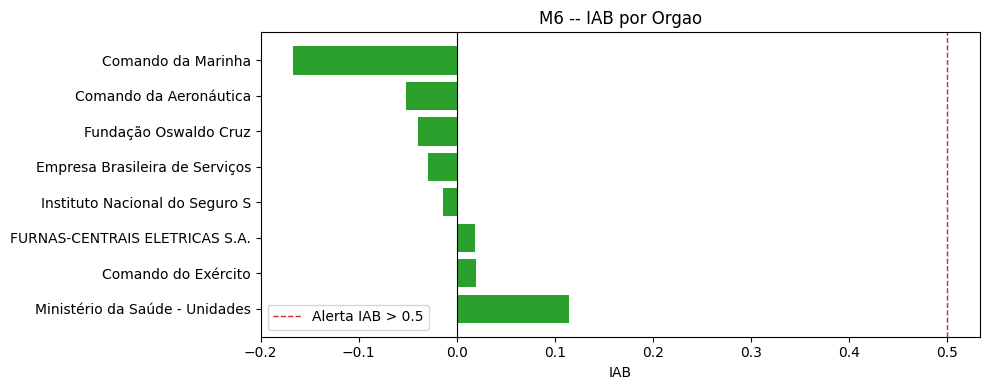

In [65]:
# ------------------------------------------------------------------
# 6.5  RESUMO IAB
# ------------------------------------------------------------------
df_iab = pd.DataFrame(iab_results).sort_values('IAB', ascending=False)
print('\n=== M6 -- Indice de Anomalia de Bunching por Orgao ===')
print(df_iab.to_string(index=False))

colors = ['#d62728' if v > 0.5 else '#2ca02c' for v in df_iab['IAB']]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df_iab['Nome'], df_iab['IAB'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.5, color='#d62728', linestyle='--', lw=1, label='Alerta IAB > 0.5')
ax.set_title('M6 -- IAB por Orgao'); ax.set_xlabel('IAB')
ax.legend(); plt.tight_layout(); plt.show()

---
## M7 -- Beneficiary Network
> Grafo bipartido orgao-fornecedor · degree centrality · betweenness · alerta CNPJ < 12 meses.

In [66]:
# !pip install networkx


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [67]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import networkx as nx
# from matplotlib.lines import Line2D
# from pyspark.sql import functions as F
# from pyspark.sql.functions import col

In [68]:
# # ------------------------------------------------------------------
# # 7.1  EXTRACAO DOS DADOS
# # ------------------------------------------------------------------
# # Detecta colunas disponiveis no schema real
# _cols = df_result.columns
# ORGAO_CODE = next((c for c in _cols if 'digo' in c and 'rg' in c), _cols[0])
# ORGAO_NAME = next((c for c in _cols if 'Nome' in c and 'rg' in c), _cols[1])
# CONTRATO   = next((c for c in _cols if 'Contrato' in c or 'CNPJ' in c), _cols[2])

# pdf_net = (
#     df_result
#     .filter(col('suspeito') == True)
#     .select(ORGAO_CODE, ORGAO_NAME, CONTRATO, 'value', 'score', 'ano', 'mes')
#     .dropna()
#     .toPandas()
#     .rename(columns={ORGAO_CODE: 'cod_orgao', ORGAO_NAME: 'nome_orgao',
#                      CONTRATO: 'fornecedor'})
# )
# print(f'[M7] Registros suspeitos: {len(pdf_net):,}')

[M7] Registros suspeitos: 643,053


In [69]:
# # ------------------------------------------------------------------
# # 7.2  FILTRO CNPJ < 12 MESES
# # ------------------------------------------------------------------
# # Heuristica: contratos nos primeiros 12 meses do dataset
# # Quando disponivel coluna 'Data Abertura CNPJ', substituir aqui
# min_ano = int(pdf_net['ano'].min())
# min_mes = int(pdf_net['mes'].min())
# cutoff  = pd.Period(f'{min_ano}-{min_mes:02d}') + 12

# pdf_net['periodo'] = pd.PeriodIndex(
#     pdf_net['ano'].astype(str) + '-' + pdf_net['mes'].astype(str).str.zfill(2),
#     freq='M')
# pdf_net['cnpj_recente'] = pdf_net['periodo'] <= cutoff

# n_rec = pdf_net['cnpj_recente'].sum()
# print(f'[M7] Contratos com fornecedor recente (<12 meses): {n_rec} '
#       f'({n_rec/len(pdf_net):.1%})')

[M7] Contratos com fornecedor recente (<12 meses): 81146 (12.6%)


In [70]:
# # ------------------------------------------------------------------
# # 7.3  GRAFO BIPARTIDO
# # ------------------------------------------------------------------
# # Nos tipo O = orgao (bipartite=0)
# # Nos tipo F = fornecedor (bipartite=1)
# # Arestas = contratos suspeitos; peso = soma dos valores
# G = nx.Graph()

# edge_data = (
#     pdf_net
#     .groupby(['cod_orgao', 'fornecedor'])
#     .agg(total_value=('value', 'sum'),
#          n_contratos=('value', 'count'),
#          score_max=('score', 'max'),
#          cnpj_recente=('cnpj_recente', 'any'))
#     .reset_index()
# )

# for _, row in edge_data.iterrows():
#     o_id = f"O_{row['cod_orgao']}"
#     f_id = f"F_{row['fornecedor']}"

#     if not G.has_node(o_id):
#         nome = pdf_net[pdf_net['cod_orgao'] == row['cod_orgao']]['nome_orgao'].iloc[0]
#         G.add_node(o_id, bipartite=0, label=nome[:20], tipo='orgao')

#     if not G.has_node(f_id):
#         G.add_node(f_id, bipartite=1, label=str(row['fornecedor'])[:15],
#                    tipo='fornecedor', cnpj_recente=bool(row['cnpj_recente']))

#     G.add_edge(o_id, f_id,
#                weight=float(row['total_value']),
#                n_contratos=int(row['n_contratos']),
#                score_max=float(row['score_max']))

# print(f'[M7] Grafo: {G.number_of_nodes()} nos, {G.number_of_edges()} arestas')

[M7] Grafo: 23665 nos, 82575 arestas


In [71]:
# # ------------------------------------------------------------------
# # 7.4  METRICAS DE CENTRALIDADE
# # ------------------------------------------------------------------
# degree_cent      = nx.degree_centrality(G)
# betweenness_cent = nx.betweenness_centrality(
#     G,
#     k=500,             
#     weight='weight',
#     normalized=True,
#     seed=42
# )

# nx.set_node_attributes(G, degree_cent,      'degree_centrality')
# nx.set_node_attributes(G, betweenness_cent, 'betweenness_centrality')

# forn_nodes = [n for n, d in G.nodes(data=True) if d.get('tipo') == 'fornecedor']
# df_cent = pd.DataFrame([{
#     'Fornecedor':       n.replace('F_', ''),
#     'Grau':             G.degree(n),
#     'Degree Cent':      round(degree_cent[n], 4),
#     'Betweenness':      round(betweenness_cent[n], 4),
#     'CNPJ Recente':     G.nodes[n].get('cnpj_recente', False),
#     'Valor Total (R$)': round(sum(G[n][nb]['weight'] for nb in G.neighbors(n)), 2),
# } for n in forn_nodes]).sort_values('Degree Cent', ascending=False)

# print('\n=== M7 -- Top Fornecedores por Degree Centrality ===')
# print(df_cent.head(15).to_string(index=False))

KeyboardInterrupt: 

In [ ]:
# # ------------------------------------------------------------------
# # 7.5  VISUALIZACAO (top-40 nos por centralidade)
# # ------------------------------------------------------------------
# top_nodes = sorted(degree_cent, key=degree_cent.get, reverse=True)[:40]
# H   = G.subgraph(top_nodes)
# pos = nx.spring_layout(H, seed=42, k=1.5)

# node_colors, node_sizes = [], []
# for n in H.nodes():
#     tipo    = H.nodes[n].get('tipo', 'fornecedor')
#     recente = H.nodes[n].get('cnpj_recente', False)
#     dc      = degree_cent.get(n, 0)
#     if tipo == 'orgao':
#         node_colors.append('#1f77b4'); node_sizes.append(600 + dc * 3000)
#     elif recente:
#         node_colors.append('#d62728'); node_sizes.append(300 + dc * 2000)
#     else:
#         node_colors.append('#2ca02c'); node_sizes.append(200 + dc * 1500)

# edge_weights = [H[u][v].get('weight', 1) for u, v in H.edges()]
# max_w = max(edge_weights) if edge_weights else 1
# edge_widths = [0.3 + 3.0 * (w / max_w) for w in edge_weights]

# fig, ax = plt.subplots(figsize=(16, 10))
# nx.draw_networkx_edges(H, pos, ax=ax, width=edge_widths, alpha=0.35, edge_color='#888')
# nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
#                        node_size=node_sizes, alpha=0.9)
# nx.draw_networkx_labels(H, pos, ax=ax,
#                         labels={n: H.nodes[n].get('label', n) for n in H.nodes()},
#                         font_size=6)
# legend_elements = [
#     Line2D([0],[0], marker='o', color='w', markerfacecolor='#1f77b4',
#            markersize=10, label='Orgao'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ca02c',
#            markersize=10, label='Fornecedor'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor='#d62728',
#            markersize=10, label='Fornecedor CNPJ <12 meses'),
# ]
# ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
# ax.set_title('M7 -- Grafo Bipartido Orgao-Fornecedor (contratos suspeitos)\n'
#              'Tamanho = Degree Centrality  |  Espessura = Valor Total',
#              fontsize=13, fontweight='bold')
# ax.axis('off'); plt.tight_layout(); plt.show()

In [ ]:
# # ------------------------------------------------------------------
# # 7.6  ALERTAS CRITICOS
# # ------------------------------------------------------------------
# alertas_m7 = df_cent[
#     (df_cent['CNPJ Recente'] == True) &
#     (df_cent['Degree Cent'] >= df_cent['Degree Cent'].quantile(0.75))
# ].sort_values('Valor Total (R$)', ascending=False)

# print(f'\n=== M7 -- {len(alertas_m7)} fornecedores recentes com alta centralidade ===')
# if not alertas_m7.empty:
#     print(alertas_m7.to_string(index=False))
# else:
#     print('  Nenhum alerta critico encontrado.')

In [ ]:
# # ------------------------------------------------------------------
# # 7.7  DISTRIBUICAO DE GRAU
# # ------------------------------------------------------------------
# degrees = [d for _, d in H.degree()]
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.hist(degrees, bins=max(degrees)+1 if degrees else 10,
#         color='#1f77b4', alpha=0.7)
# ax.set_title('M7 -- Distribuicao de Grau (subgrafo top-40)')
# ax.set_xlabel('Grau'); ax.set_ylabel('Frequencia')
# ax.grid(True, linestyle='--', alpha=0.4)
# plt.tight_layout(); plt.show()